# 02 – Feature Engineering

In this notebook we:

- Apply the preprocessing pipeline from `src/preprocess.py`.
- Add handcrafted features in `src/feature_engineering.py`.
- Explore the new features.
- Explain why these features can help the model.


In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append(os.path.abspath(".."))

from src.preprocess import load_raw_data, merge_datasets, basic_cleaning, split_train_valid
from src.feature_engineering import (
    add_handcrafted_features,
    get_feature_lists,
)

plt.rcParams["figure.figsize"] = (10, 6)
sns.set(style="whitegrid")

In [5]:
train_transaction, train_identity, test_transaction, test_identity = load_raw_data(
    data_dir="../data/raw"
)
train_merged = merge_datasets(train_transaction, train_identity)
train_clean = basic_cleaning(train_merged)
train_df, valid_df = split_train_valid(train_clean, target_col="isFraud")

train_df.head()

,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
40809,0,1008491,100.00,R,6177,399.0,150.0,american express,150.0,credit,...,ie 11.0 for desktop,24.0,1920x1080,match_status:2,T,F,T,T,desktop,Trident/7.0
285886,0,7008212,29.99,W,7900,345.0,150.0,mastercard,224.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
104256,0,2071522,107.95,W,11690,111.0,150.0,visa,226.0,credit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
507860,0,13299752,241.95,W,2616,327.0,150.0,discover,102.0,credit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
196382,0,4412283,117.00,W,13780,298.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
train_fe = add_handcrafted_features(train_df.copy())
valid_fe = add_handcrafted_features(valid_df.copy())

train_fe[["TransactionAmt", "TransactionAmt_log", "Transaction_day", "Transaction_hour"]].head()

,TransactionAmt,TransactionAmt_log,Transaction_day,Transaction_hour
40809,100.00,4.615121,11,16
285886,29.99,3.433665,81,2
104256,107.95,4.690889,23,23
507860,241.95,5.492856,153,22
196382,117.00,4.770685,51,1


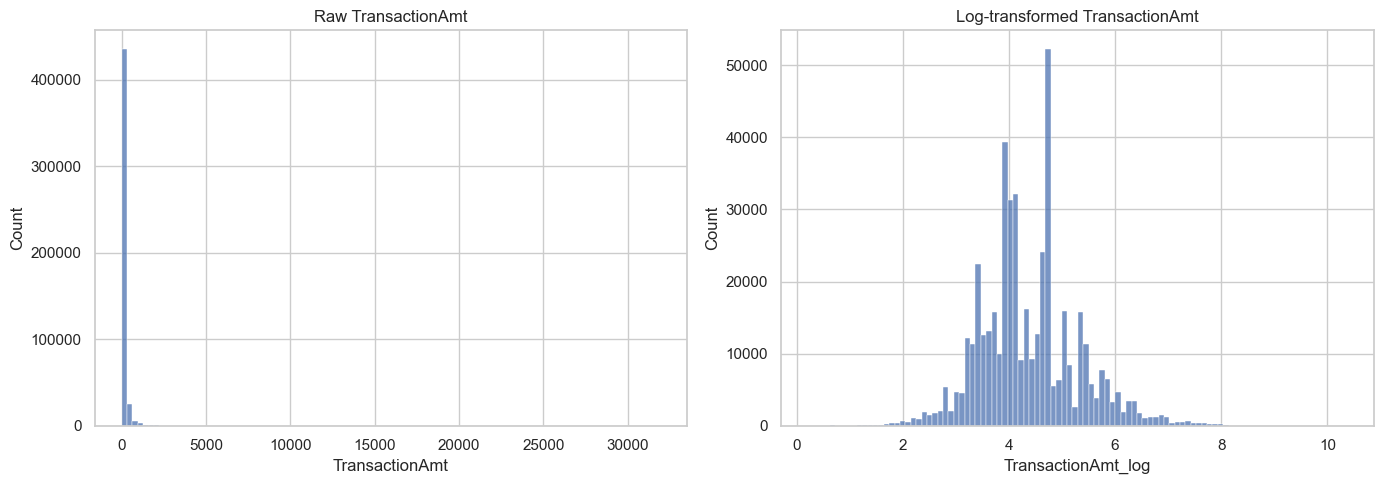

<Figure size 1000x600 with 0 Axes>

In [7]:
# Compare original and log-transformed transaction amount
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train_fe["TransactionAmt"].dropna(), bins=100, ax=axes[0])
axes[0].set_title("Raw TransactionAmt")

sns.histplot(train_fe["TransactionAmt_log"].dropna(), bins=100, ax=axes[1])
axes[1].set_title("Log-transformed TransactionAmt")

plt.tight_layout()
plt.show()
plt.savefig("../docs/images/feature_importance1.png", dpi=200, bbox_inches="tight")


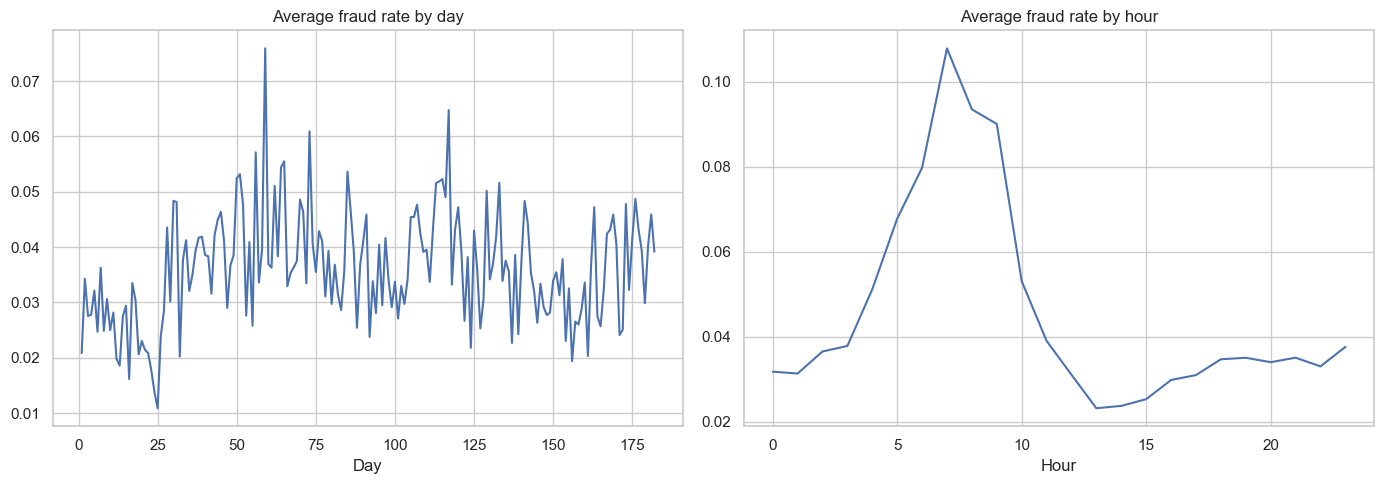

<Figure size 1000x600 with 0 Axes>

In [8]:
# Average fraud rate by day and hour
day_fraud_rate = train_fe.groupby("Transaction_day")["isFraud"].mean()
hour_fraud_rate = train_fe.groupby("Transaction_hour")["isFraud"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

day_fraud_rate.plot(ax=axes[0])
axes[0].set_title("Average fraud rate by day")
axes[0].set_xlabel("Day")

hour_fraud_rate.plot(ax=axes[1])
axes[1].set_title("Average fraud rate by hour")
axes[1].set_xlabel("Hour")

plt.tight_layout()
plt.show()
plt.savefig("../docs/images/feature_importance2.png", dpi=200, bbox_inches="tight")


## Why these features help

- `TransactionAmt_log`: The log transformation reduces the effect of very large amounts.
  This often makes patterns easier for the model to learn.
- `Transaction_day` and `Transaction_hour`: Fraud can be time-dependent.
  For example, some days or hours of the day may have higher fraud risk due to specific attacks.

We will use these features in the training pipeline.
